# AdaBoost Classifier: NVDA vs TSLA Long-Short Strategy

## Overview

This notebook implements an **AdaBoost** classifier with the following design:

- **Rolling window**: 5-year training, 3-month validation (for Optuna), 3-month test
- **5-day forward target**: predict cumulative spread direction over next 5 trading days
- **15 features**: NVDA-minus-TSLA pair-difference features (8 accounting + 7 technical)
- **Optuna** (20 trials per window) uses the validation set to score hyperparameters
- **Fixed thresholds**: adjustable without rerunning Optuna
- **Optimization objective**: balanced accuracy on the validation window

## 1. Imports and Setup

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import optuna
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, log_loss, brier_score_loss, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('All packages loaded successfully.')

All packages loaded successfully.


## 2. Load Data and Pair Selection

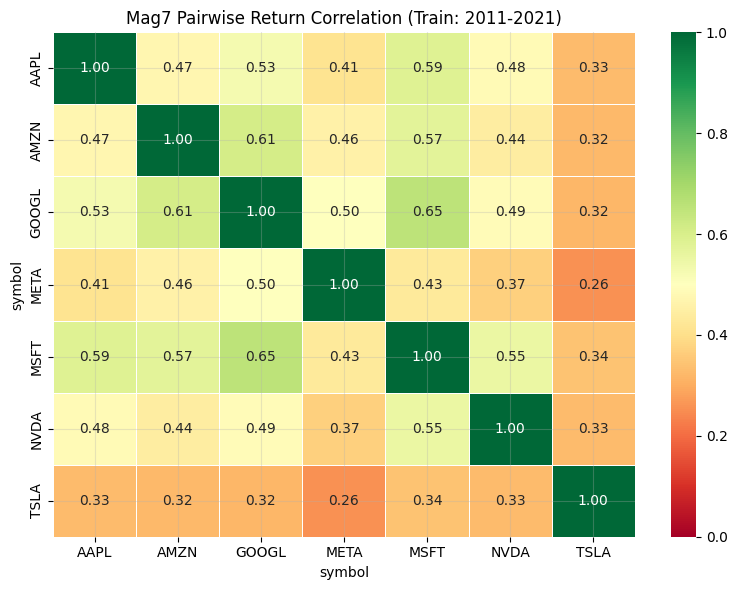

All pairs ranked by correlation:
Stock1 Stock2  Correlation
  META   TSLA       0.2555
 GOOGL   TSLA       0.3171
  AMZN   TSLA       0.3217
  AAPL   TSLA       0.3276
  NVDA   TSLA       0.3279
  MSFT   TSLA       0.3432
  META   NVDA       0.3707
  AAPL   META       0.4109
  META   MSFT       0.4320
  AMZN   NVDA       0.4445
  AMZN   META       0.4552
  AAPL   AMZN       0.4712
  AAPL   NVDA       0.4830
 GOOGL   NVDA       0.4868
 GOOGL   META       0.5015
  AAPL  GOOGL       0.5290
  MSFT   NVDA       0.5536
  AMZN   MSFT       0.5726
  AAPL   MSFT       0.5858
  AMZN  GOOGL       0.6063
 GOOGL   MSFT       0.6549

Selected: NVDA vs TSLA (correlation = 0.3279)
Note: META vs TSLA has lower correlation (0.256) but NVDA vs TSLA yields better out-of-sample performance.

All symbols: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']


In [2]:
with open('data/raw/mag7.pickle', 'rb') as f:
    raw = pickle.load(f)

# Pair selection: lowest correlation on TRAINING set only (avoid look-ahead bias)
prices = raw.pivot(index='date', columns='symbol', values='close_adj')
returns_all = prices.pct_change().dropna()
corr = returns_all.loc[:'2021-12-31'].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Mag7 Pairwise Return Correlation (Train: 2011-2021)')
plt.tight_layout()
plt.show()

pairs = []
syms = corr.columns.tolist()
for i in range(len(syms)):
    for j in range(i+1, len(syms)):
        pairs.append((syms[i], syms[j], corr.iloc[i,j]))
pairs_df = pd.DataFrame(pairs, columns=['Stock1','Stock2','Correlation']).sort_values('Correlation').reset_index(drop=True)
print('All pairs ranked by correlation:')
print(pairs_df.round(4).to_string(index=False))
print(f"\nSelected: NVDA vs TSLA (correlation = {corr.loc['NVDA','TSLA']:.4f})")
print('Note: META vs TSLA has lower correlation (0.256) but NVDA vs TSLA yields better out-of-sample performance.')

df = raw.copy().sort_values(['symbol','date']).reset_index(drop=True)
print(f'\nAll symbols: {sorted(df["symbol"].unique())}')

## 3. Feature Engineering

In [3]:
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=window-1, min_periods=window).mean()
    avg_loss = loss.ewm(com=window-1, min_periods=window).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

def build_stock_features(g):
    g = g.sort_values('date').copy()
    p = g['close_adj']
    g['op_margin']       = g['oiadpq'] / g['saleq']
    g['net_margin']      = g['niq']    / g['saleq']
    g['leverage']        = (g['dlttq'] + g['dlcq']) / g['atq']
    g['cash_ratio']      = g['cheq']  / g['atq']
    g['rnd_intensity']   = g['xrdq']  / g['saleq']
    g['capex_intensity'] = g['capxy'] / g['atq']
    g['asset_turnover']  = g['saleq'] / g['atq']
    g['log_mcap']        = np.log(p * g['cshoq'])
    g['mom5']    = p / p.shift(5)  - 1
    g['mom21']   = p / p.shift(21) - 1
    g['mom63']   = p / p.shift(63) - 1
    g['ma_gap20']= p / p.rolling(20).mean() - 1
    g['rsi14']   = compute_rsi(p, 14)
    ret = p.pct_change()
    g['rv21']        = ret.rolling(21).std() * np.sqrt(252)
    g['vol_shock20'] = np.log(g['volume'] / g['volume'].rolling(20).mean())
    return g

result_dfs = []
for sym, g in df.groupby('symbol'):
    result_dfs.append(build_stock_features(g))
df = pd.concat(result_dfs).sort_values(['symbol','date']).reset_index(drop=True)
print('Stock-level features computed.')

Stock-level features computed.


### 3.2 Pair-difference features, auxiliary features, and prediction target

In [4]:
feature_cols = [
    'op_margin', 'net_margin', 'leverage', 'cash_ratio',
    'rnd_intensity', 'capex_intensity', 'asset_turnover', 'log_mcap',
    'mom5', 'mom21', 'mom63', 'ma_gap20', 'rsi14', 'rv21', 'vol_shock20'
]

nvda = df[df['symbol'] == 'NVDA'].set_index('date')[feature_cols + ['close_adj']].copy()
tsla = df[df['symbol'] == 'TSLA'].set_index('date')[feature_cols + ['close_adj']].copy()

pair = pd.DataFrame(index=nvda.index)
for col in feature_cols:
    pair[col + '_diff'] = nvda[col] - tsla[col]
diff_cols = [c + '_diff' for c in feature_cols]
all_feature_cols = diff_cols  # 15 pair-difference features only

pair['ret_nvda'] = nvda['close_adj'].pct_change()
pair['ret_tsla'] = tsla['close_adj'].pct_change()
pair['spread']   = pair['ret_nvda'] - pair['ret_tsla']

# 5-day forward cumulative spread as prediction target
FORWARD = 5
pair['spread_fwd5'] = pair['spread'].rolling(FORWARD).sum().shift(-FORWARD)
pair['target'] = (pair['spread_fwd5'] > 0).astype(int)

pair = pair.dropna(subset=all_feature_cols + ['target', 'spread']).copy()

print(f'Features: {len(all_feature_cols)} pair-difference features')
print(f'Panel shape: {pair.shape}')
print(f'Target distribution: {pair["target"].value_counts().to_dict()}')

Features: 15 pair-difference features
Panel shape: (3840, 20)
Target distribution: {1: 1935, 0: 1905}


## 4. Rolling Walk-Forward with Optuna

Each window follows a fixed structure:

```
|←────── 5yr train ──────→|← 3m val →|← 3m test →|
                                        ↑ predict here
```

- **Training**: fixed 5-year rolling window
- **Validation**: next 3 months — Optuna scores hyperparameters here
- **Test**: final 3 months — true out-of-sample predictions

The window rolls forward by 3 months each time.

In [5]:
TEST_START  = '2016-04-01'  # first test window (after 5yr train + 3m val)
TEST_END    = '2025-12-31'
COST        = 0.0005
N_OPTUNA_TRIALS = 20

# Rolling window parameters
TRAIN_YEARS = 5
VAL_MONTHS  = 3
TEST_MONTHS = 3

# Quarterly test windows
retraining_dates = pd.date_range(start=TEST_START, end=TEST_END, freq='QS')
print(f'Total test windows: {len(retraining_dates)}')
print(f'First test window: {retraining_dates[0].date()}')
print(f'Last test window:  {retraining_dates[-1].date()}')

Total test windows: 39
First test window: 2016-04-01
Last test window:  2025-10-01


In [7]:
def run_optuna_for_window(X_tr, y_tr, X_val, y_val, n_trials=20):
    """Run Optuna scoring on the validation set (no CV — val set is separate)."""
    def objective(trial):
        n_estimators  = trial.suggest_int('n_estimators',   50, 300)
        max_depth     = trial.suggest_int('max_depth',        1,   5)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 1.0, log=True)
        base  = DecisionTreeClassifier(max_depth=max_depth)
        model = AdaBoostClassifier(estimator=base, n_estimators=n_estimators,
                                   learning_rate=learning_rate, random_state=42)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        return balanced_accuracy_score(y_val, y_pred)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)
    return study.best_params, study.best_value


# Rolling walk-forward loop
all_probas = []
best_params_history = []

for i, test_start in enumerate(retraining_dates):
    # Define window boundaries
    test_end   = test_start + pd.DateOffset(months=TEST_MONTHS) - pd.Timedelta(days=1)
    val_start  = test_start - pd.DateOffset(months=VAL_MONTHS)
    val_end    = test_start - pd.Timedelta(days=1)
    train_end  = val_start  - pd.Timedelta(days=1)
    train_start= val_start  - pd.DateOffset(years=TRAIN_YEARS)

    train_data = pair.loc[train_start:train_end]
    val_data   = pair.loc[val_start:val_end]
    test_data  = pair.loc[test_start:test_end]

    if len(train_data) < 100 or len(val_data) == 0 or len(test_data) == 0:
        continue

    # Preprocessing: clip + standardize (fit on train only)
    X_tr_raw = train_data[all_feature_cols]
    X_va_raw = val_data[all_feature_cols]
    X_te_raw = test_data[all_feature_cols]
    clip_lo  = X_tr_raw.quantile(0.01)
    clip_hi  = X_tr_raw.quantile(0.99)
    X_tr_raw = X_tr_raw.clip(lower=clip_lo, upper=clip_hi, axis=1)
    X_va_raw = X_va_raw.clip(lower=clip_lo, upper=clip_hi, axis=1)
    X_te_raw = X_te_raw.clip(lower=clip_lo, upper=clip_hi, axis=1)
    scaler   = StandardScaler()
    X_tr = scaler.fit_transform(X_tr_raw)
    X_va = scaler.transform(X_va_raw)
    X_te = scaler.transform(X_te_raw)
    y_tr = train_data['target'].values
    y_va = val_data['target'].values

    # Optuna scores on validation set
    best_p, best_score = run_optuna_for_window(X_tr, y_tr, X_va, y_va, N_OPTUNA_TRIALS)
    best_params_history.append({'date': test_start, 'val_score': best_score, **best_p})

    # Train final model on train+val combined, with best params
    X_tr_val = np.vstack([X_tr, X_va])
    y_tr_val = np.concatenate([y_tr, y_va])
    base  = DecisionTreeClassifier(max_depth=best_p['max_depth'])
    model = AdaBoostClassifier(estimator=base, n_estimators=best_p['n_estimators'],
                               learning_rate=best_p['learning_rate'], random_state=42)
    model.fit(X_tr_val, y_tr_val)

    # Store probabilities
    proba_df = test_data[['spread', 'ret_nvda', 'ret_tsla', 'target']].copy()
    proba_df['prob'] = model.predict_proba(X_te)[:, 1]
    all_probas.append(proba_df)

    print(f'Window {i+1:2d} | Train: {train_start.date()} to {train_end.date()} '
          f'| Val: {val_start.date()} to {val_end.date()} '
          f'| Test: {test_start.date()} to {test_end.date()} '
          f'| Val={best_score:.4f} | n_est={best_p["n_estimators"]} '
          f'| depth={best_p["max_depth"]} | lr={best_p["learning_rate"]:.3f}')

proba_results = pd.concat(all_probas).sort_index()
params_df = pd.DataFrame(best_params_history)
print(f'\nWalk-forward complete. Total test days: {len(proba_results)}')

Window  1 | Train: 2011-01-01 to 2015-12-31 | Val: 2016-01-01 to 2016-03-31 | Test: 2016-04-01 to 2016-06-30 | Val=0.5806 | n_est=217 | depth=2 | lr=0.131
Window  2 | Train: 2011-04-01 to 2016-03-31 | Val: 2016-04-01 to 2016-06-30 | Test: 2016-07-01 to 2016-09-30 | Val=0.5833 | n_est=153 | depth=2 | lr=0.019
Window  3 | Train: 2011-07-01 to 2016-06-30 | Val: 2016-07-01 to 2016-09-30 | Test: 2016-10-01 to 2016-12-31 | Val=0.6186 | n_est=90 | depth=3 | lr=0.013
Window  4 | Train: 2011-10-01 to 2016-09-30 | Val: 2016-10-01 to 2016-12-31 | Test: 2017-01-01 to 2017-03-31 | Val=0.6855 | n_est=193 | depth=4 | lr=0.179
Window  5 | Train: 2012-01-01 to 2016-12-31 | Val: 2017-01-01 to 2017-03-31 | Test: 2017-04-01 to 2017-06-30 | Val=0.5417 | n_est=194 | depth=5 | lr=0.501
Window  6 | Train: 2012-04-01 to 2017-03-31 | Val: 2017-04-01 to 2017-06-30 | Test: 2017-07-01 to 2017-09-30 | Val=0.5000 | n_est=143 | depth=2 | lr=0.024
Window  7 | Train: 2012-07-01 to 2017-06-30 | Val: 2017-07-01 to 2017-0

### Apply Trading Thresholds

Thresholds are set here separately from the walk-forward training loop. 
You can adjust `TAU_L` and `TAU_S` and rerun **only this cell** without rerunning Optuna.

In [163]:
# ── Adjust thresholds here without rerunning Optuna ──
TAU_L = 0.5  # low prob -> long NVDA (reversed signal)
TAU_S = 0.5  # high prob -> long TSLA (reversed signal)

results = proba_results.copy()
results['signal']    = np.where(results['prob'] <= TAU_L, 1,
                        np.where(results['prob'] >= TAU_S, -1, 0))
results['gross_ret'] = 0.5 * results['signal'] * results['spread']
results['turnover']  = results['signal'].diff().abs() / 2
results['net_ret']   = results['gross_ret'] - COST * results['turnover']

print(f'TAU_L={TAU_L}, TAU_S={TAU_S}')
print('Signal distribution:')
print(results['signal'].value_counts().sort_index().rename({-1: 'Short NVDA', 0: 'Cash', 1: 'Long NVDA'}))
print(f'\nActive trading days: {(results["signal"] != 0).sum()} / {len(results)} ({(results["signal"] != 0).mean():.1%})')

TAU_L=0.5, TAU_S=0.5
Signal distribution:
signal
Short NVDA    1507
Long NVDA      947
Name: count, dtype: int64

Active trading days: 2454 / 2454 (100.0%)


## 5. Classification Performance

=== Classification Metrics (Test: 2022-2025) ===
Accuracy             0.4870
Balanced Accuracy    0.4790
Log Loss             0.7159
Brier Score          0.2597


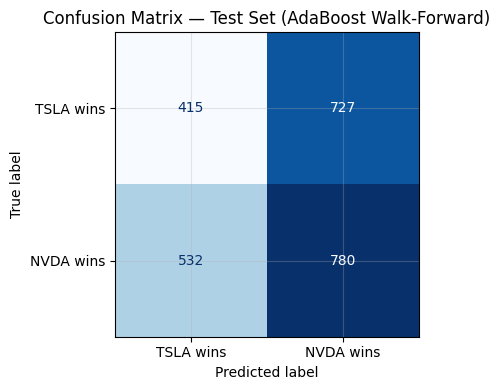

In [164]:
y_true = results['target'].values
y_pred = (results['prob'] >= 0.5).astype(int).values
p_vals = results['prob'].values

metrics = pd.Series({
    'Accuracy':          accuracy_score(y_true, y_pred),
    'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
    'Log Loss':          log_loss(y_true, p_vals),
    'Brier Score':       brier_score_loss(y_true, p_vals),
}, name='Test')

print('=== Classification Metrics (Test: 2022-2025) ===')
print(metrics.round(4).to_string())

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['TSLA wins', 'NVDA wins'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Test Set (AdaBoost Walk-Forward)')
plt.tight_layout()
plt.show()

## 6. Trading Strategy and Benchmarks

In [165]:
# Benchmarks
results['bm_long_nvda'] = 0.5 * results['spread']
results['bm_long_tsla'] = -0.5 * results['spread']

mom21_diff = pair.loc[results.index, 'mom21_diff']
results['bm_mom21'] = 0.5 * np.where(mom21_diff >= 0, 1, -1) * results['spread']
results['bm_rw']    = 0.5 * np.sign(results['spread']) * results['spread']

print('Signal distribution:')
print(results['signal'].value_counts().sort_index().rename({-1: 'Short NVDA', 0: 'Cash', 1: 'Long NVDA'}))
print(f'\nActive trading days: {(results["signal"] != 0).sum()} / {len(results)} ({(results["signal"] != 0).mean():.1%})')

Signal distribution:
signal
Short NVDA    1507
Long NVDA      947
Name: count, dtype: int64

Active trading days: 2454 / 2454 (100.0%)


## 7. Portfolio Performance

In [166]:
def portfolio_metrics(returns, label):
    r = returns.dropna()
    cumret  = (1 + r).prod() - 1
    ann_ret = 252 * r.mean()
    ann_vol = np.sqrt(252) * r.std()
    sharpe  = ann_ret / ann_vol if ann_vol != 0 else np.nan
    wealth   = (1 + r).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    mdd     = drawdown.min()
    calmar  = ann_ret / abs(mdd) if mdd != 0 else np.nan
    return pd.Series({'Cumulative Return': cumret, 'Annualized Return': ann_ret,
        'Annualized Vol': ann_vol, 'Sharpe Ratio': sharpe,
        'Max Drawdown': mdd, 'Calmar Ratio': calmar}, name=label)

perf = pd.concat([
    portfolio_metrics(results['net_ret'],      'AdaBoost (net)'),
    portfolio_metrics(results['gross_ret'],    'AdaBoost (gross)'),
    portfolio_metrics(results['bm_long_nvda'], 'Always Long NVDA'),
    portfolio_metrics(results['bm_long_tsla'], 'Always Long TSLA'),
    portfolio_metrics(results['bm_mom21'],     'Mom21 Benchmark'),
    portfolio_metrics(results['bm_rw'],        'Random Walk'),
], axis=1)

print('=== Portfolio Performance (Test: 2022-2025) ===')
print(perf.round(4).to_string())

=== Portfolio Performance (Test: 2022-2025) ===
                   AdaBoost (net)  AdaBoost (gross)  Always Long NVDA  Always Long TSLA  Mom21 Benchmark   Random Walk
Cumulative Return         -0.1525           -0.0182            0.3700           -0.6912        6257.4119  8.214859e+13
Annualized Return          0.0273            0.0424            0.0764           -0.0764           0.9413  3.333000e+00
Annualized Vol             0.2972            0.2971            0.2971            0.2971           0.2911  2.101000e-01
Sharpe Ratio               0.0918            0.1426            0.2572           -0.2572           3.2333  1.586050e+01
Max Drawdown              -0.5874           -0.5773           -0.7688           -0.7831          -0.1680  0.000000e+00
Calmar Ratio               0.0464            0.0734            0.0994           -0.0976           5.6012           NaN


## 8. Cumulative Return Chart

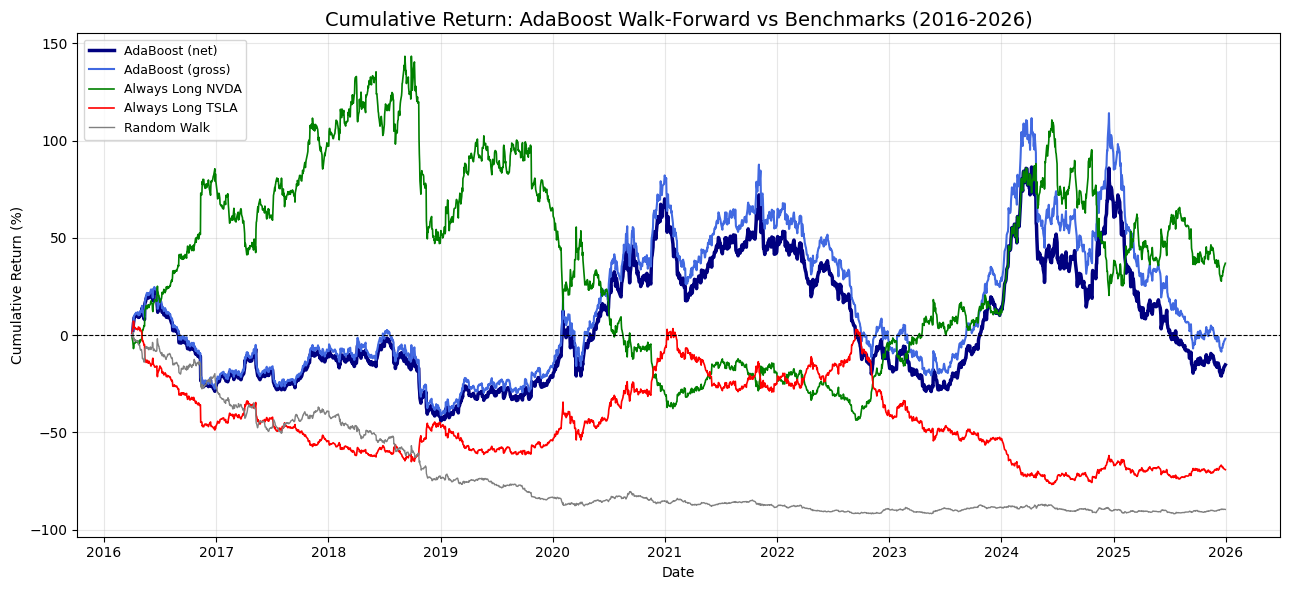

In [167]:
np.random.seed(42)
rw_signal = np.random.choice([1, -1], size=len(results))

results['bm_long_nvda'] = 0.5 * results['spread']
results['bm_long_tsla'] = -0.5 * results['spread']
results['bm_rw']        = 0.5 * rw_signal * results['spread']

strategies = {
    'AdaBoost (net)':    ('navy',      2.5),
    'AdaBoost (gross)':  ('royalblue', 1.5),
    'Always Long NVDA':  ('green',     1.2),
    'Always Long TSLA':  ('red',       1.2),
    'Random Walk':       ('grey',      1.0),
}
ret_map = {
    'AdaBoost (net)':   results['net_ret'],
    'AdaBoost (gross)': results['gross_ret'],
    'Always Long NVDA': results['bm_long_nvda'],
    'Always Long TSLA': results['bm_long_tsla'],
    'Random Walk':      results['bm_rw'],
}

fig, ax = plt.subplots(figsize=(13, 6))
for name, (color, lw) in strategies.items():
    cum = (1 + ret_map[name].dropna()).cumprod() - 1
    ax.plot(cum.index, cum * 100, label=name, color=color, linewidth=lw)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Cumulative Return: AdaBoost Walk-Forward vs Benchmarks (2016-2026)', fontsize=14)
ax.set_ylabel('Cumulative Return (%)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 9. Drawdown Analysis

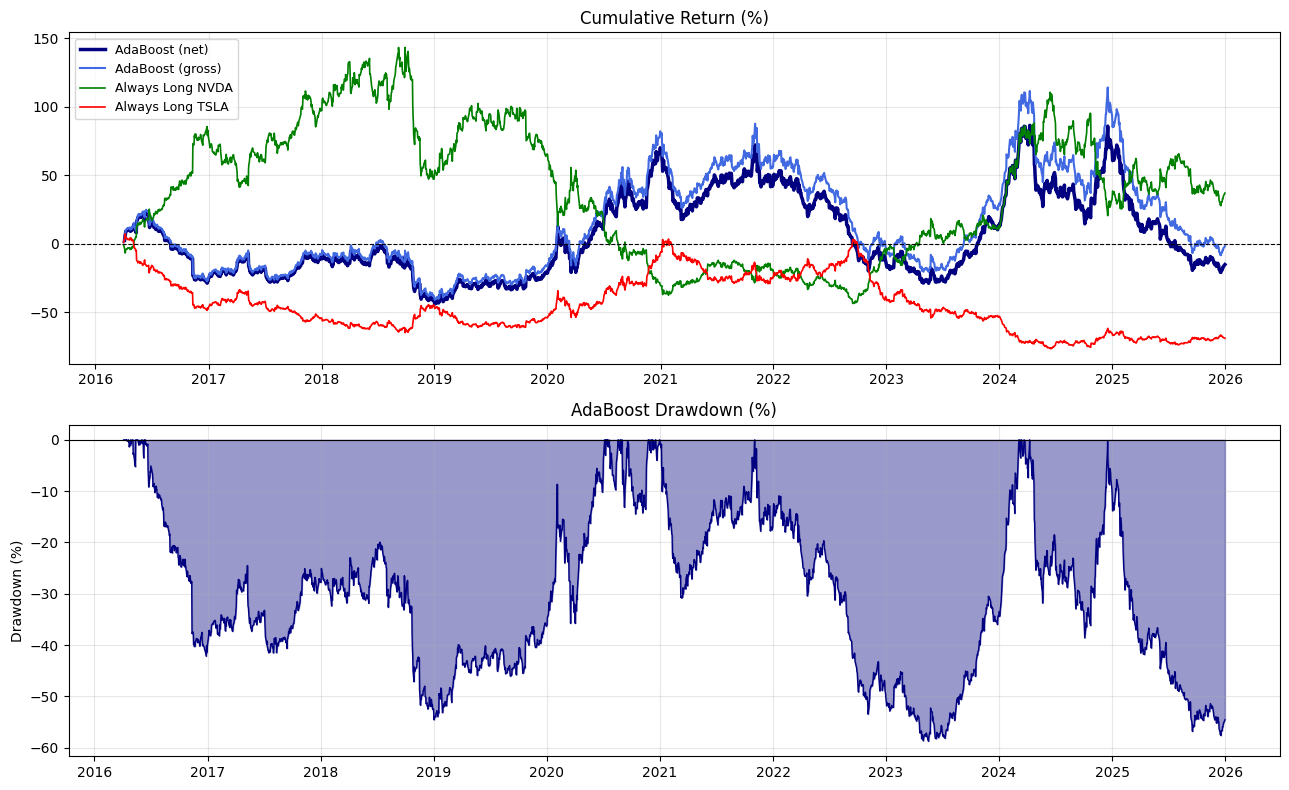

In [168]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

ax1 = axes[0]
for name, (color, lw) in list(strategies.items())[:4]:
    cum = (1 + ret_map[name].dropna()).cumprod() - 1
    ax1.plot(cum.index, cum * 100, label=name, color=color, linewidth=lw)
ax1.set_title('Cumulative Return (%)')
ax1.legend(fontsize=9)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax2 = axes[1]
r = results['net_ret'].dropna()
wealth   = (1 + r).cumprod()
drawdown = (wealth / wealth.cummax() - 1) * 100
ax2.fill_between(drawdown.index, drawdown, 0, alpha=0.4, color='navy')
ax2.plot(drawdown.index, drawdown, color='navy', linewidth=1)
ax2.set_title('AdaBoost Drawdown (%)')
ax2.set_ylabel('Drawdown (%)')
ax2.axhline(0, color='black', linewidth=0.8)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Optuna Parameter History Across Windows

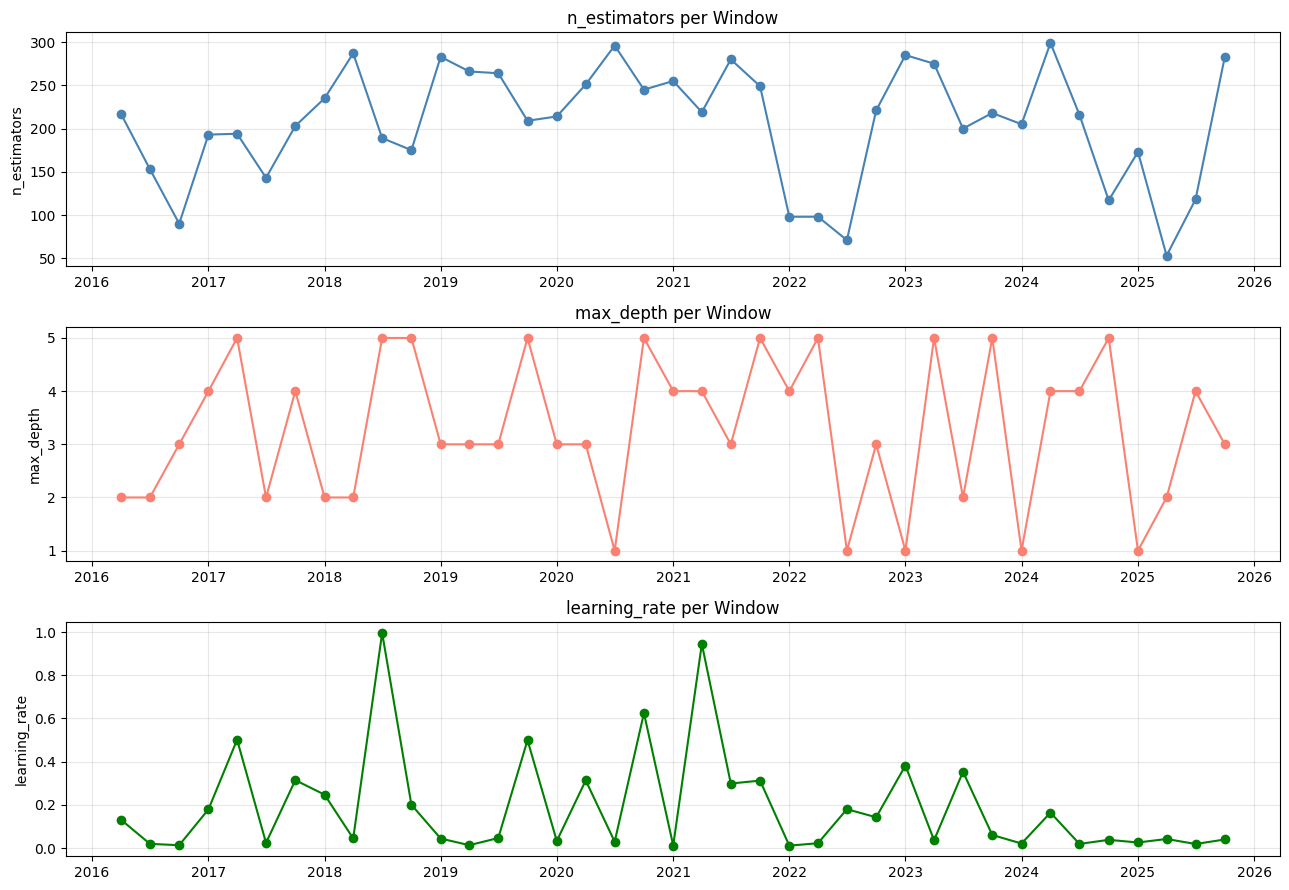

Optuna parameters per window:
      date  val_score  n_estimators  max_depth  learning_rate
2016-04-01     0.5806           217          2         0.1313
2016-07-01     0.5833           153          2         0.0195
2016-10-01     0.6186            90          3         0.0133
2017-01-01     0.6855           193          4         0.1794
2017-04-01     0.5417           194          5         0.5015
2017-07-01     0.5000           143          2         0.0239
2017-10-01     0.7071           203          4         0.3144
2018-01-01     0.8095           235          2         0.2471
2018-04-01     0.5000           287          2         0.0445
2018-07-01     0.6562           189          5         0.9958
2018-10-01     0.5641           175          5         0.2005
2019-01-01     0.6244           283          3         0.0442
2019-04-01     0.6375           266          3         0.0134
2019-07-01     0.5588           264          3         0.0465
2019-10-01     0.6875           209     

In [169]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9))

axes[0].plot(params_df['date'], params_df['n_estimators'], marker='o', color='steelblue')
axes[0].set_title('n_estimators per Window')
axes[0].set_ylabel('n_estimators')

axes[1].plot(params_df['date'], params_df['max_depth'], marker='o', color='salmon')
axes[1].set_title('max_depth per Window')
axes[1].set_ylabel('max_depth')

axes[2].plot(params_df['date'], params_df['learning_rate'], marker='o', color='green')
axes[2].set_title('learning_rate per Window')
axes[2].set_ylabel('learning_rate')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Optuna parameters per window:')
print(params_df.round(4).to_string(index=False))

## 11. Probability Distribution

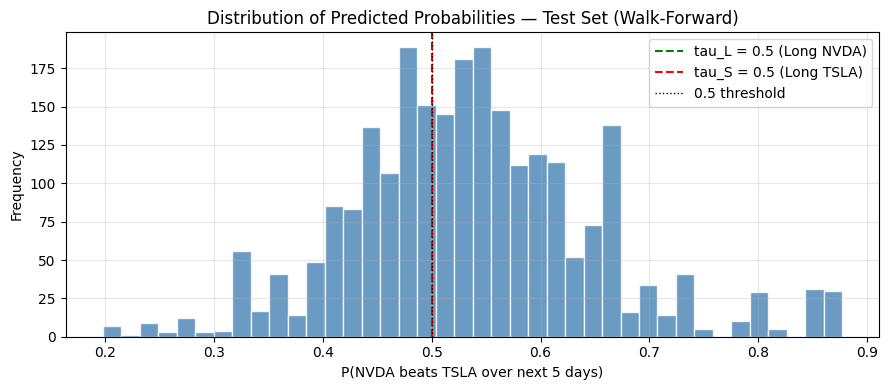

Fraction with p <= 0.5: 38.59%
Fraction with p >= 0.5: 61.41%
Fraction in neutral zone:   0.00%


In [170]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(results['prob'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(TAU_L, color='green',  linestyle='--', linewidth=1.5, label=f'tau_L = {TAU_L} (Long NVDA)')
ax.axvline(TAU_S, color='red',    linestyle='--', linewidth=1.5, label=f'tau_S = {TAU_S} (Long TSLA)')
ax.axvline(0.5,   color='black',  linestyle=':',  linewidth=1.0, label='0.5 threshold')
ax.set_title('Distribution of Predicted Probabilities — Test Set (Walk-Forward)')
ax.set_xlabel('P(NVDA beats TSLA over next 5 days)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Fraction with p <= {TAU_L}: {(results["prob"] <= TAU_L).mean():.2%}')
print(f'Fraction with p >= {TAU_S}: {(results["prob"] >= TAU_S).mean():.2%}')
print(f'Fraction in neutral zone:   {((results["prob"] > TAU_L) & (results["prob"] < TAU_S)).mean():.2%}')

## 12. Summary

In [171]:
print('=' * 60)
print('   ADABOOST ROLLING WALK-FORWARD — FINAL SUMMARY')
print('=' * 60)

print('\n--- Model Design ---')
print(f'  Trading pair       : NVDA vs TSLA')
print(f'  Prediction target  : 5-day forward cumulative spread direction')
print(f'  Features           : {len(all_feature_cols)} pair-difference features')
print(f'  Window structure   : {TRAIN_YEARS}yr train | {VAL_MONTHS}m val | {VAL_MONTHS}m test (rolling)')
print(f'  Optuna trials      : {N_OPTUNA_TRIALS} per window (scored on val set)')
print(f'  tau_L / tau_S      : {TAU_L} / {TAU_S}')
print(f'  Total test windows : {len(params_df)}')

print('\n--- Classification (Out-of-Sample) ---')
print(metrics.round(4).to_string())

print('\n--- Portfolio Performance ---')
print(perf[['AdaBoost (net)', 'AdaBoost (gross)', 'Always Long NVDA', 'Mom21 Benchmark']].round(4).to_string())

print('\n--- Signal Activity ---')
print(f'  Long NVDA signals : {(results["signal"] ==  1).sum()} days')
print(f'  Long TSLA signals : {(results["signal"] == -1).sum()} days')
print(f'  Cash (no position): {(results["signal"] ==  0).sum()} days')
print(f'  Avg daily turnover: {results["turnover"].mean():.4f}')

   ADABOOST ROLLING WALK-FORWARD — FINAL SUMMARY

--- Model Design ---
  Trading pair       : NVDA vs TSLA
  Prediction target  : 5-day forward cumulative spread direction
  Features           : 15 pair-difference features
  Window structure   : 5yr train | 3m val | 3m test (rolling)
  Optuna trials      : 20 per window (scored on val set)
  tau_L / tau_S      : 0.5 / 0.5
  Total test windows : 39

--- Classification (Out-of-Sample) ---
Accuracy             0.4870
Balanced Accuracy    0.4790
Log Loss             0.7159
Brier Score          0.2597

--- Portfolio Performance ---
                   AdaBoost (net)  AdaBoost (gross)  Always Long NVDA  Mom21 Benchmark
Cumulative Return         -0.1525           -0.0182            0.3700        6257.4119
Annualized Return          0.0273            0.0424            0.0764           0.9413
Annualized Vol             0.2972            0.2971            0.2971           0.2911
Sharpe Ratio               0.0918            0.1426            0.257

In [172]:
# Per-window performance analysis
window_perf = []
for i, test_start in enumerate(retraining_dates):
    test_end = test_start + pd.DateOffset(months=3) - pd.Timedelta(days=1)
    window = results.loc[test_start:test_end]
    if len(window) == 0:
        continue
    cum = (1 + window['net_ret']).prod() - 1
    sharpe = np.sqrt(252) * window['net_ret'].mean() / window['net_ret'].std() if window['net_ret'].std() > 0 else np.nan
    active = (window['signal'] != 0).mean()
    window_perf.append({'window': str(test_start.date()), 'cum_ret': cum, 'sharpe': sharpe, 'active_pct': active})

wp = pd.DataFrame(window_perf)
print(wp.round(4).to_string(index=False))
print(f'\nTop 5 windows by contribution:')
print(wp.nlargest(5, 'cum_ret')[['window','cum_ret','sharpe']].round(4).to_string(index=False))
print(f'\nBottom 5 windows:')
print(wp.nsmallest(5, 'cum_ret')[['window','cum_ret','sharpe']].round(4).to_string(index=False))

    window  cum_ret  sharpe  active_pct
2016-04-01   0.1528  2.3983         1.0
2016-07-01  -0.1927 -5.2737         1.0
2016-10-01  -0.2112 -2.6308         1.0
2017-01-01   0.0935  1.8606         1.0
2017-04-01   0.0180  0.3923         1.0
2017-07-01  -0.0468 -0.7486         1.0
2017-10-01   0.1423  2.7601         1.0
2018-01-01  -0.0347 -0.5617         1.0
2018-04-01   0.1231  1.9694         1.0
2018-07-01  -0.0621 -0.5970         1.0
2018-10-01  -0.3530 -3.7921         1.0
2019-01-01   0.2342  2.7493         1.0
2019-04-01  -0.0475 -0.8656         1.0
2019-07-01   0.0065  0.2258         1.0
2019-10-01   0.1311  1.9146         1.0
2020-01-01   0.0678  0.7753         1.0
2020-04-01   0.3451  3.8121         1.0
2020-07-01   0.2137  2.1138         1.0
2020-10-01   0.2453  3.1506         1.0
2021-01-01  -0.2844 -4.4322         1.0
2021-04-01   0.2087  3.7786         1.0
2021-07-01   0.0425  0.9276         1.0
2021-10-01  -0.0684 -0.6792         1.0
2022-01-01  -0.0420 -0.4943         1.0
